## Imports

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
import os
pd.set_option('display.max_rows', None)

## Read in datasets to create race dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Akin
dataframes = {
    'circuits_df': pd.read_csv('/content/drive/MyDrive/f1db_csv/circuits.csv'),
    'constructor_standings_df': pd.read_csv('/content/drive/MyDrive/f1db_csv/constructor_standings.csv'),
    'constructors_df': pd.read_csv('/content/drive/MyDrive/f1db_csv/constructors.csv'),
    'driver_standings_df': pd.read_csv('/content/drive/MyDrive/f1db_csv/driver_standings.csv'),
    'drivers_df': pd.read_csv('/content/drive/MyDrive/f1db_csv/drivers.csv'),
    'races_df': pd.read_csv('/content/drive/MyDrive/f1db_csv/races.csv'),
    'results_df': pd.read_csv('/content/drive/MyDrive/f1db_csv/results.csv'),
    'status_df': pd.read_csv('/content/drive/MyDrive/f1db_csv/status.csv')
}

In [ ]:
# Gia
dataframes = {
    'circuits_df': pd.read_csv('/content/drive/My Drive/200_Final_Project/f1db_csv/circuits.csv'),
    'constructor_standings_df': pd.read_csv('/content/drive/My Drive/200_Final_Project/f1db_csv/constructor_standings.csv'),
    'constructors_df': pd.read_csv('/content/drive/My Drive/200_Final_Project/f1db_csv/constructors.csv'),
    'driver_standings_df': pd.read_csv('/content/drive/My Drive/200_Final_Project/f1db_csv/driver_standings.csv'),
    'drivers_df': pd.read_csv('/content/drive/My Drive/200_Final_Project/f1db_csv/drivers.csv'),
    'races_df': pd.read_csv('/content/drive/My Drive/200_Final_Project/f1db_csv/races.csv'),
    'results_df': pd.read_csv('/content/drive/My Drive/200_Final_Project/f1db_csv/results.csv'),
    'status_df': pd.read_csv('/content/drive/My Drive/200_Final_Project/f1db_csv/status.csv')
}

In [ ]:
# Cat
dataframes = {
    'circuits_df': pd.read_csv('/content/drive/My Drive/200: Final Project/f1db_csv/circuits.csv'),
    'constructor_standings_df': pd.read_csv('/content/drive/My Drive/200: Final Project/f1db_csv/constructor_standings.csv'),
    'constructors_df': pd.read_csv('/content/drive/My Drive/200: Final Project/f1db_csv/constructors.csv'),
    'driver_standings_df': pd.read_csv('/content/drive/My Drive/200: Final Project/f1db_csv/driver_standings.csv'),
    'drivers_df': pd.read_csv('/content/drive/My Drive/200: Final Project/f1db_csv/drivers.csv'),
    'races_df': pd.read_csv('/content/drive/My Drive/200: Final Project/f1db_csv/races.csv'),
    'results_df': pd.read_csv('/content/drive/My Drive/200: Final Project/f1db_csv/results.csv'),
    'status_df': pd.read_csv('/content/drive/My Drive/200: Final Project/f1db_csv/status.csv')
}

In [ ]:
circuits_df = dataframes['circuits_df']
constructor_standings_df = dataframes['constructor_standings_df']
constructors_df = dataframes['constructors_df']
driver_standings_df = dataframes['driver_standings_df']
drivers_df = dataframes['drivers_df']
races_df = dataframes['races_df']
results_df = dataframes['results_df']
status_df = dataframes['status_df']

## Merge dataframes to create race dataset

In [ ]:
race_circuits = pd.merge(races_df, circuits_df, on='circuitId', how='left', suffixes=('_race', '_circuits'))
res_race_circuits = pd.merge(results_df, race_circuits, on='raceId', how='left', suffixes=('_results', '_race'))
merge_driver_df = pd.merge(res_race_circuits, drivers_df, on='driverId', how='left', suffixes=('_race', '_drivers'))
merge_status_df = pd.merge(merge_driver_df, status_df, on='statusId', how='left', suffixes=('_drivers', '_status'))
merge_constructors_df = pd.merge(merge_status_df, constructors_df, on='constructorId', how='left', suffixes=('_status', '_constructors'))
merge_drivers_standing_df = pd.merge(merge_constructors_df, driver_standings_df, on=['raceId', 'driverId'], how='left', suffixes=('_constructors', '_drivers'))
merge_constructors_standing_df = pd.merge(merge_drivers_standing_df, constructor_standings_df, on=['raceId', 'constructorId'], how='left', suffixes=('_driver', '_constructor'))

In [ ]:
filtered_df = merge_constructors_standing_df[(merge_constructors_standing_df['year'] >= 2018) & (merge_constructors_standing_df['year'] <= 2022)].reset_index()

In [ ]:
cols_to_keep = [
    'driverId', 'forename', 'surname', 'name',
    'raceId', 'date', 'time_race', 'location', 'country', 'lat', 'lng',
    'name_circuits', 'circuitRef',  'round',
    'grid', 'position_constructors', 'laps', 'fastestLap', 'milliseconds','points_constructors',
    'status', 'points_drivers', 'position_drivers', 'points', 'position'
]

race_df = filtered_df[cols_to_keep]

In [ ]:
rename_dict = {
    'forename': 'first_name',
    'surname': 'last_name',
    'name': 'team_name',
    'date': 'race_date',
    'time_race': 'scheduled_time',
    'name_circuits': 'circuit_name',
    'circuitRef': 'circuit_ref',
    'grid': 'starting_race_position',
    'position_constructors': 'ending_race_position',
    'points_constructors': 'race_points',
    'points_drivers': 'driver_current_points',
    'position_drivers': 'driver_current_position',
    'milliseconds': 'race_time',
    'fastestLap': 'fastest_lap',
    'points': 'constructor_current_points',
    'position': 'constructor_current_position'
}

race_df = race_df.rename(columns=rename_dict)

In [ ]:
# pd.set_option('display.max_columns', 500)
race_df.head()

,driverId,first_name,last_name,team_name,raceId,race_date,scheduled_time,location,country,lat,...,ending_race_position,laps,fastest_lap,race_time,race_points,status,driver_current_points,driver_current_position,constructor_current_points,constructor_current_position
0,20,Sebastian,Vettel,Ferrari,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,...,1,58,53,5373283,25.0,Finished,25.0,1.0,40.0,1.0
1,1,Lewis,Hamilton,Mercedes,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,...,2,58,50,5378319,18.0,Finished,18.0,2.0,22.0,2.0
2,8,Kimi,Räikkönen,Ferrari,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,...,3,58,57,5379592,15.0,Finished,15.0,3.0,40.0,1.0
3,817,Daniel,Ricciardo,Red Bull,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,...,4,58,54,5380352,12.0,Finished,12.0,4.0,20.0,3.0
4,4,Fernando,Alonso,McLaren,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,...,5,58,57,5401169,10.0,Finished,10.0,5.0,12.0,4.0


In [ ]:
race_df.dtypes

driverId                          int64
first_name                       object
last_name                        object
team_name                        object
raceId                            int64
race_date                        object
scheduled_time                   object
location                         object
country                          object
lat                             float64
lng                             float64
circuit_name                     object
circuit_ref                      object
round                             int64
starting_race_position            int64
ending_race_position             object
laps                              int64
fastest_lap                      object
race_time                        object
race_points                     float64
status                           object
driver_current_points           float64
driver_current_position         float64
constructor_current_points      float64
constructor_current_position    float64


## Use this table for weather API

In [ ]:
cols_for_api = ['circuit_name', 'location', 'country', 'lat', 'lng', 'race_date', 'scheduled_time']

In [ ]:
weather_loc_df = race_df.groupby('raceId')[cols_for_api].first().reset_index()

In [ ]:
pd.set_option('display.max_rows', 500)
weather_loc_df.head(103)

,raceId,circuit_name,location,country,lat,lng,race_date,scheduled_time
0,989,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.96800,2018-03-25,05:10:00
1,990,Bahrain International Circuit,Sakhir,Bahrain,26.0325,50.51060,2018-04-08,15:10:00
2,991,Shanghai International Circuit,Shanghai,China,31.3389,121.22000,2018-04-15,06:10:00
3,992,Baku City Circuit,Baku,Azerbaijan,40.3725,49.85330,2018-04-29,12:10:00
4,993,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.5700,2.26111,2018-05-13,13:10:00
5,994,Circuit de Monaco,Monte-Carlo,Monaco,43.7347,7.42056,2018-05-27,13:10:00
6,995,Circuit Gilles Villeneuve,Montreal,Canada,45.5000,-73.52280,2018-06-10,18:10:00
7,996,Circuit Paul Ricard,Le Castellet,France,43.2506,5.79167,2018-06-24,14:10:00
8,997,Red Bull Ring,Spielberg,Austria,47.2197,14.76470,2018-07-01,13:10:00
9,998,Silverstone Circuit,Silverstone,UK,52.0786,-1.01694,2018-07-08,13:10:00


In [ ]:
weather_loc_df.shape

(103, 8)

In [ ]:
weather_loc_df.to_csv('/content/drive/My Drive/200: Final Project/weather_dataFrames/weather_loc_df.csv')

In [ ]:
# https://www.weather.gov/lox/rainrate - This gives an idea of precipitation, which is measured by the hour

In [ ]:
# Akin's path
weather_data = pd.read_csv('/content/drive/My Drive/weather_dataFrames/weather_dataset.csv', index_col=0)


In [ ]:
weather_data = weather_data.reset_index().drop(['index'], axis=1)

In [ ]:
weather_data.head()

,date,temperature_2m,precipitation,wind_speed_10m,wind_direction_10m,race_id,hour
0,2018-03-25 05:00:00,74.225296,0.0,17.609894,295.58847,989,5
1,2018-03-25 06:00:00,73.145300,0.0,16.783464,291.09240,989,6
2,2018-03-25 07:00:00,70.985306,0.0,17.571490,301.46408,989,7
3,2018-03-25 08:00:00,68.555300,0.0,13.243720,322.54935,989,8
4,2018-03-25 09:00:00,67.205300,0.0,10.054064,290.85452,989,9


In [ ]:
weather_data.shape

(514, 7)

In [ ]:
weather_data[weather_data.precipitation > 0].shape

(89, 7)

In [ ]:
# Defining raining conditions
weather_data['wet_conditions'] = (weather_data.precipitation > 0).astype(int)

In [ ]:
# # convert wind speed from m/s to mph
# weather_data['wind_mph'] = weather_data.wind_speed_10m * 2.237

In [ ]:
# Defining windy conditions, https://www.weather.gov/pqr/wind
weather_data['windy_conditions'] = (weather_data.wind_speed_10m > 25).astype(int)

In [ ]:
# Defining hot and cold conditions. Using 25% and 75% quartile values to define hot and cold temperatures
weather_data['cold_conditions'] = (weather_data.temperature_2m < 66).astype(int)
weather_data['hot_conditions'] = (weather_data.temperature_2m > 79).astype(int)

In [ ]:
weather_data.head()

,date,temperature_2m,precipitation,wind_speed_10m,wind_direction_10m,race_id,hour,wet_conditions,windy_conditions,cold_conditions,hot_conditions
0,2018-03-25 05:00:00,74.225296,0.0,17.609894,295.58847,989,5,0,0,0,0
1,2018-03-25 06:00:00,73.145300,0.0,16.783464,291.09240,989,6,0,0,0,0
2,2018-03-25 07:00:00,70.985306,0.0,17.571490,301.46408,989,7,0,0,0,0
3,2018-03-25 08:00:00,68.555300,0.0,13.243720,322.54935,989,8,0,0,0,0
4,2018-03-25 09:00:00,67.205300,0.0,10.054064,290.85452,989,9,0,0,0,0


In [ ]:
weather_data.temperature_2m.value_counts()

69.526400    4
79.950200    3
62.630600    3
82.650200    3
64.118300    3
72.663800    2
67.188200    2
67.847000    2
81.450500    2
65.402600    2
54.630500    2
80.460495    2
78.908000    2
67.526596    2
65.648300    2
71.768300    2
67.615700    2
77.156600    2
67.652600    2
68.732600    2
82.080500    2
63.932000    2
65.926400    2
67.643600    2
75.145100    2
73.396400    2
67.937000    2
77.927000    2
78.557000    2
69.224900    1
69.494900    1
69.314896    1
54.620598    1
54.710598    1
55.160600    1
55.610600    1
55.070600    1
79.593796    1
55.719498    1
82.113800    1
81.843796    1
66.884895    1
81.663800    1
80.403800    1
81.720500    1
82.350500    1
55.809500    1
68.552600    1
55.179500    1
69.092600    1
68.912600    1
68.504900    1
83.546600    1
71.348000    1
83.636604    1
72.046400    1
64.260500    1
70.246400    1
84.355700    1
85.795700    1
86.065700    1
85.435700    1
83.995700    1
60.309500    1
63.990500    1
61.119500    1
62.199500 

In [ ]:
weather_data.temperature_2m.quantile(0.8)

79.5894784

In [ ]:
weather_data.describe()

,temperature_2m,precipitation,wind_speed_10m,wind_direction_10m,race_id,hour,wet_conditions,windy_conditions,cold_conditions,hot_conditions
count,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000
mean,71.649673,0.003654,8.620263,185.426530,1041.500000,15.264591,0.173152,0.003891,0.250973,0.217899
std,8.811974,0.013316,4.667269,108.235407,31.421566,3.481507,0.378747,0.062317,0.433995,0.413220
min,43.579400,0.000000,0.316360,0.987746,989.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,65.949350,0.000000,5.447451,99.338139,1014.000000,14.000000,0.000000,0.000000,0.000000,0.000000
50%,70.392650,0.000000,7.998643,173.985200,1040.000000,15.000000,0.000000,0.000000,0.000000,0.000000
75%,78.527750,0.000000,11.009119,298.879673,1069.750000,17.000000,0.000000,0.000000,0.750000,0.000000
max,95.088200,0.102362,25.964624,358.069460,1096.000000,23.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
summarized_weather = weather_data.groupby('race_id')[['wet_conditions', 'cold_conditions', 'hot_conditions', 'windy_conditions']].sum()

In [ ]:
summarized_weather.head(100)

,wet_conditions,cold_conditions,hot_conditions,windy_conditions
race_id,,,,
989,0,0,0,4
990,0,0,2,0
991,0,5,0,0
992,0,5,0,5
993,3,5,0,0
994,2,0,0,0
995,0,0,0,0
996,0,0,0,0
997,0,3,0,0


## Save datasets

In [ ]:
# race_df.to_pickle('/content/drive/My Drive/200: Final Project/race_df.pkl')
# weather_df.to_pickle('/content/drive/My Drive/200: Final Project/weather_df.pkl')

In [ ]:
race_df.head()

,driverId,first_name,last_name,team_name,raceId,race_date,scheduled_time,location,country,lat,lng,circuit_name,circuit_ref,round,starting_race_position,ending_race_position,laps,fastest_lap,race_time,race_points,status,driver_current_points,driver_current_position,constructor_current_points,constructor_current_position
0,20,Sebastian,Vettel,Ferrari,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,144.968,Albert Park Grand Prix Circuit,albert_park,1,3,1,58,53,5373283,25.0,Finished,25.0,1.0,40.0,1.0
1,1,Lewis,Hamilton,Mercedes,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,144.968,Albert Park Grand Prix Circuit,albert_park,1,1,2,58,50,5378319,18.0,Finished,18.0,2.0,22.0,2.0
2,8,Kimi,Räikkönen,Ferrari,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,144.968,Albert Park Grand Prix Circuit,albert_park,1,2,3,58,57,5379592,15.0,Finished,15.0,3.0,40.0,1.0
3,817,Daniel,Ricciardo,Red Bull,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,144.968,Albert Park Grand Prix Circuit,albert_park,1,8,4,58,54,5380352,12.0,Finished,12.0,4.0,20.0,3.0
4,4,Fernando,Alonso,McLaren,989,2018-03-25,05:10:00,Melbourne,Australia,-37.8497,144.968,Albert Park Grand Prix Circuit,albert_park,1,10,5,58,57,5401169,10.0,Finished,10.0,5.0,12.0,4.0


In [ ]:
race_df.tail()

,driverId,first_name,last_name,team_name,raceId,race_date,scheduled_time,location,country,lat,lng,circuit_name,circuit_ref,round,starting_race_position,ending_race_position,laps,fastest_lap,race_time,race_points,status,driver_current_points,driver_current_position,constructor_current_points,constructor_current_position
2055,854,Mick,Schumacher,Haas F1 Team,1096,2022-11-20,13:00:00,Abu Dhabi,UAE,24.4672,54.6031,Yas Marina Circuit,yas_marina,22,12,16,57,39,\N,0.0,+1 Lap,12.0,16.0,37.0,8.0
2056,825,Kevin,Magnussen,Haas F1 Team,1096,2022-11-20,13:00:00,Abu Dhabi,UAE,24.4672,54.6031,Yas Marina Circuit,yas_marina,22,16,17,57,40,\N,0.0,+1 Lap,25.0,13.0,37.0,8.0
2057,1,Lewis,Hamilton,Mercedes,1096,2022-11-20,13:00:00,Abu Dhabi,UAE,24.4672,54.6031,Yas Marina Circuit,yas_marina,22,5,18,55,42,\N,0.0,Hydraulics,240.0,6.0,515.0,3.0
2058,849,Nicholas,Latifi,Williams,1096,2022-11-20,13:00:00,Abu Dhabi,UAE,24.4672,54.6031,Yas Marina Circuit,yas_marina,22,20,19,55,45,\N,0.0,Collision damage,2.0,20.0,8.0,10.0
2059,4,Fernando,Alonso,Alpine F1 Team,1096,2022-11-20,13:00:00,Abu Dhabi,UAE,24.4672,54.6031,Yas Marina Circuit,yas_marina,22,10,\N,27,24,\N,0.0,Water leak,81.0,9.0,173.0,4.0


In [ ]:
race_df.dtypes

driverId                          int64
first_name                       object
last_name                        object
team_name                        object
raceId                            int64
race_date                        object
scheduled_time                   object
location                         object
country                          object
lat                             float64
lng                             float64
circuit_name                     object
circuit_ref                      object
round                             int64
starting_race_position            int64
ending_race_position             object
laps                              int64
fastest_lap                      object
race_time                        object
race_points                     float64
status                           object
driver_current_points           float64
driver_current_position         float64
constructor_current_points      float64
constructor_current_position    float64


In [ ]:
race_df.describe()

,driverId,raceId,lat,lng,round,starting_race_position,laps,race_points,driver_current_points,driver_current_position,constructor_current_points,constructor_current_position
count,2060.00000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000,2060.000000
mean,668.05000,1041.601942,34.076079,15.962748,10.883495,10.141262,54.120388,5.061408,55.478883,10.579612,110.783981,5.500000
std,328.29655,31.453178,20.726402,55.974035,6.072735,5.826781,17.826455,7.214940,76.677956,5.852648,148.730419,2.872979
min,1.00000,989.000000,-37.849700,-99.090700,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,815.00000,1014.000000,26.032500,2.261110,6.000000,5.000000,51.000000,0.000000,4.000000,6.000000,13.000000,3.000000
50%,832.00000,1040.000000,43.250600,9.281110,11.000000,10.000000,56.000000,0.250000,23.000000,11.000000,48.000000,5.500000
75%,844.00000,1070.000000,47.219700,49.853300,16.000000,15.000000,66.250000,9.000000,70.250000,16.000000,139.000000,8.000000
max,856.00000,1096.000000,52.388800,144.968000,22.000000,20.000000,87.000000,26.000000,454.000000,23.000000,759.000000,10.000000


In [ ]:
# race_df.fastest_lap.value_counts() #\N values. We should chat on how to handle \N in fastest_lap and ending_race_position columns

In [ ]:

print(f'The average number of laps per race is {race_df.laps.mean():.0f} laps')

The average number of laps per race is 54 laps


In [ ]:
# print(f'The fastest lap for each driver occurs on average in lap {race_df.fastest_lap.mean()}')

In [ ]:
temp = race_df.groupby('circuit_ref')['raceId'].nunique().to_frame('num_races').reset_index()

In [ ]:
temp.head()

,circuit_ref,num_races
0,albert_park,3
1,americas,4
2,bahrain,6
3,baku,4
4,catalunya,5


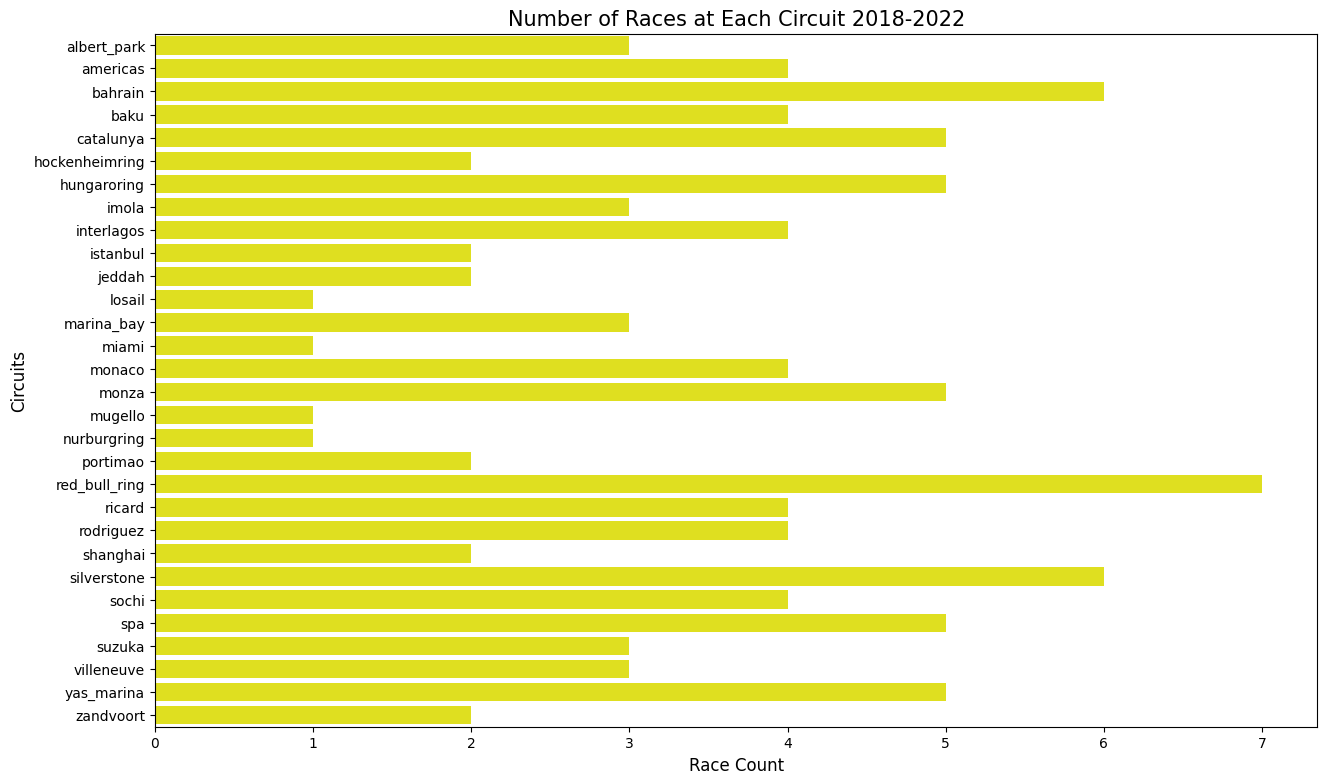

In [ ]:
plt.figure(figsize=(15, 9))
sns.barplot(x='num_races', y='circuit_ref', orient='h', data=temp, color='yellow')
plt.title("Number of Races at Each Circuit 2018-2022",fontsize=15)
plt.xlabel('Race Count', fontsize='large')
plt.ylabel('Circuits', fontsize='large')
plt.savefig('races_at_circuit.png')

In [ ]:
status = race_df.status.value_counts().reset_index()

In [ ]:
status.columns = ['status', 'count']

In [ ]:
status.head()

,status,count
0,Finished,1074
1,+1 Lap,536
2,+2 Laps,101
3,Collision,77
4,Accident,32


<Axes: xlabel='count', ylabel='status'>

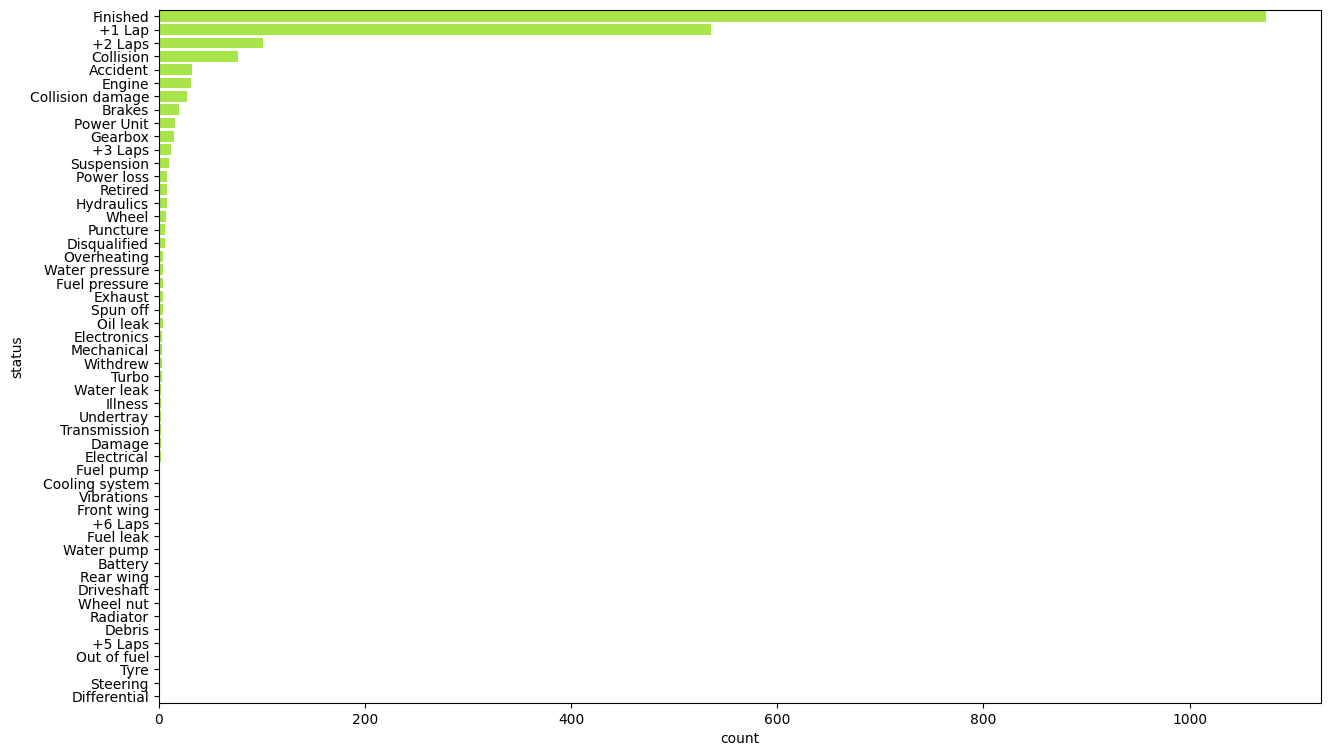

In [ ]:
plt.figure(figsize=(15, 9))
sns.barplot(x='count', y='status', orient='h', data=status, color='greenyellow')

In [ ]:
# Teams and number of entries
teams = race_df.team_name.value_counts().reset_index()
teams.columns = ['team_name', 'entries']
teams.head()

,team_name,entries
0,Ferrari,206
1,Mercedes,206
2,Red Bull,206
3,McLaren,206
4,Williams,206


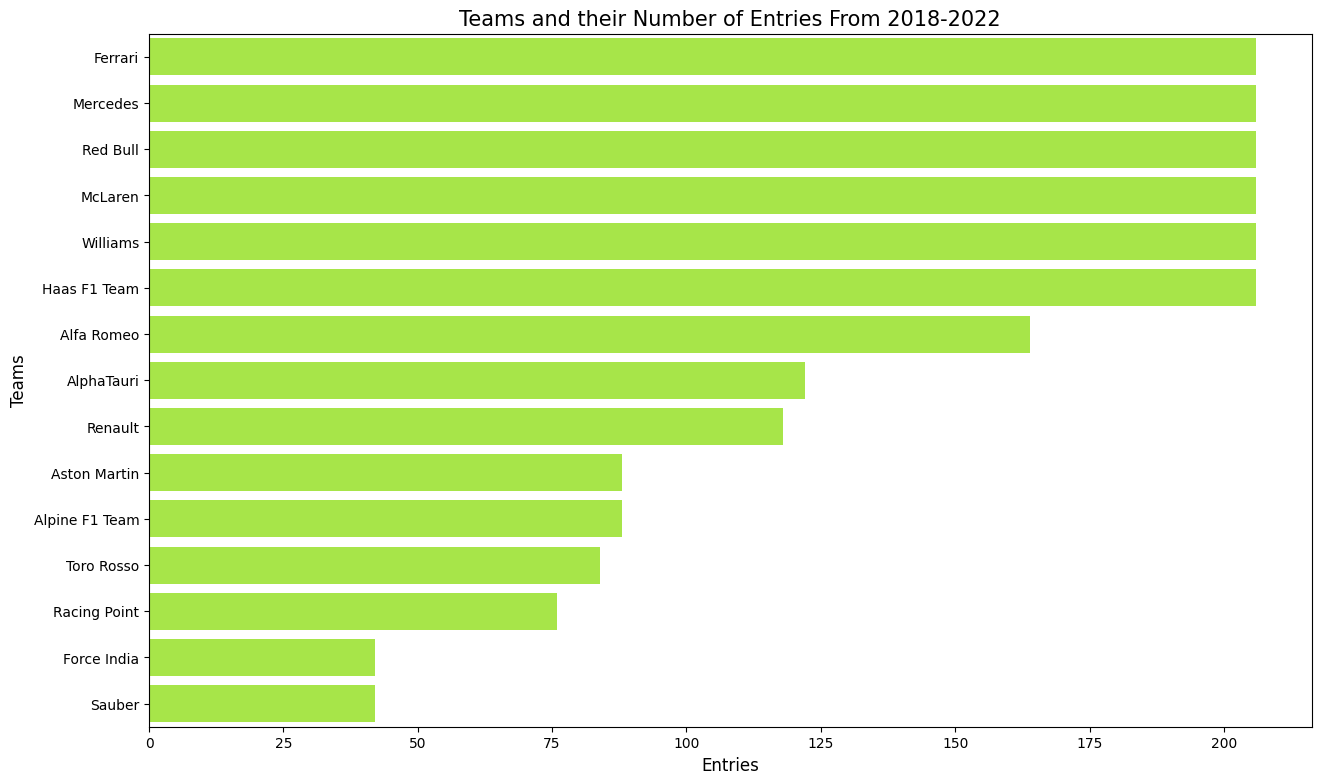

In [ ]:
plt.figure(figsize=(15, 9))
sns.barplot(x='entries', y='team_name', orient='h', data=teams, color='greenyellow')
plt.title("Teams and their Number of Entries From 2018-2022",fontsize=15)
plt.xlabel('Entries', fontsize='large')
plt.ylabel('Teams', fontsize='large')
plt.savefig('entries_per_team.png')

In [ ]:
drivers = race_df.last_name.value_counts().reset_index()
drivers.columns = ['driver', 'entries']
drivers.head()


,driver,entries
0,Gasly,103
1,Sainz,103
2,Ricciardo,103
3,Verstappen,103
4,Leclerc,103


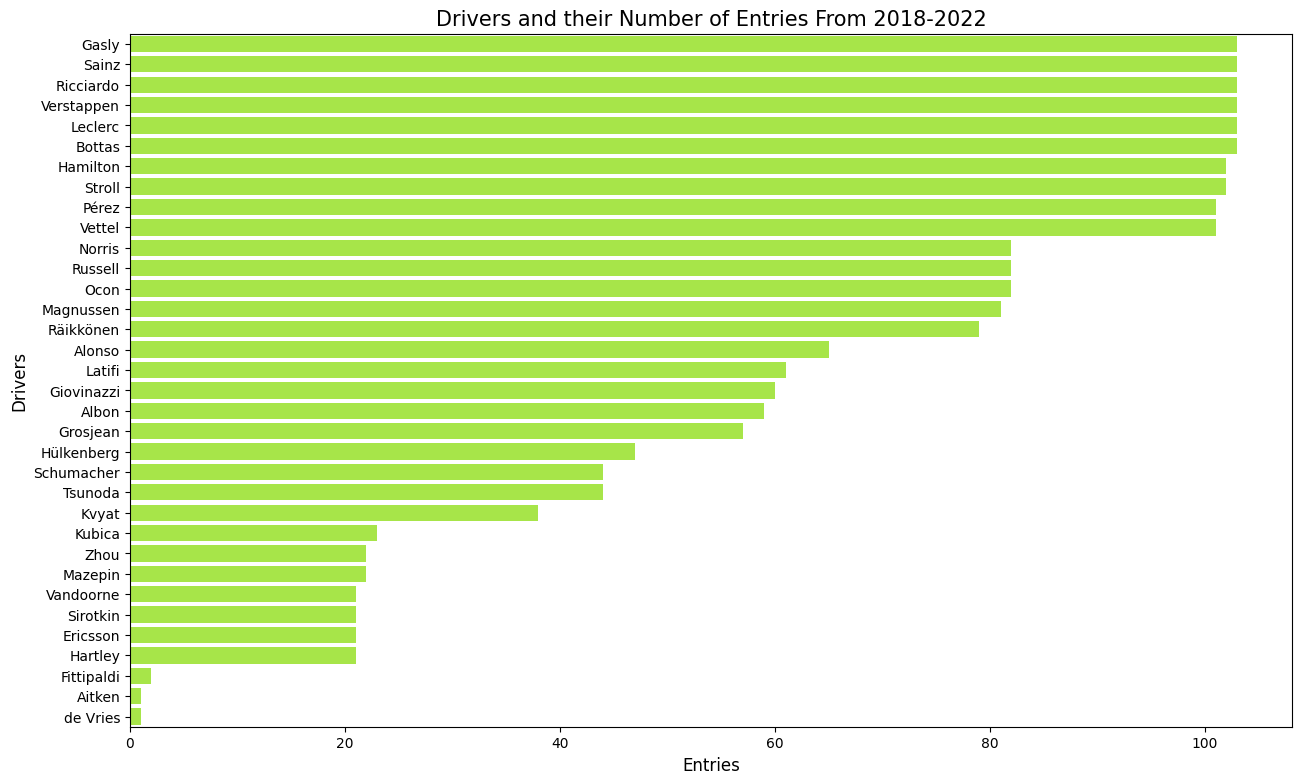

In [ ]:
plt.figure(figsize=(15, 9))
sns.barplot(x='entries', y='driver', orient='h', data=drivers, color='greenyellow')
plt.title("Drivers and their Number of Entries From 2018-2022",fontsize=15)
plt.xlabel('Entries', fontsize='large')
plt.ylabel('Drivers', fontsize='large')
plt.savefig('entries_per_driver.png')

## Chart for Proposal

In [ ]:
# Akin
# Creating chart for proposal
weather_samp = pd.read_csv('/content/drive/MyDrive/weather_dataFrames/1036_weather.csv', index_col=0)

In [ ]:
# convert to datetime
weather_samp['date'] = pd.to_datetime(weather_samp['date'])
# Extract the hour
weather_samp['hour'] = weather_samp['date'].dt.hour

In [ ]:
plt.figure(figsize=(15, 9))
sns.barplot(x='hour', y='temperature_2m', data=weather_samp, color='yellow')
plt.title("Temperature at the hour for the Spanish GP, Barcelona on 2020-08-16 ",fontsize=15)
plt.xlabel('Hour', fontsize='large')
plt.ylabel('Temperature (F)', fontsize='large')
# plt.savefig('weather.png')